In [179]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

In [180]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data/sample"

SAMPLE_ID = "44b6_0113de3b"

PROCESSED_DIR = (
        DATA_ROOT
        / "processed"
        / "stage_6_processed_dataset"
        / SAMPLE_ID
)

DETECTION_DIR = PROCESSED_DIR / "detection"

In [181]:
detection_files = sorted(DETECTION_DIR.glob("t*.csv"))

detections = [
    pd.read_csv(file)
    for file in detection_files
]

print(f"Loaded {len(detections)} timepoints.")

Loaded 20 timepoints.


In [182]:
detections[0].head()

,cell_id,centroid_z,centroid_y,centroid_x,volume_voxels,z_min,y_min,x_min,z_max,y_max,x_max
0,1,0.231183,6.354839,52.204301,186.0,0,0,46,2,14,60
1,2,0.153153,6.815315,71.774775,222.0,0,0,65,2,16,80
2,3,0.320833,26.012500,65.191667,240.0,0,18,59,4,35,72
3,4,1.074627,62.743555,58.230665,737.0,0,55,48,4,72,68
4,5,0.364431,98.571429,34.836735,343.0,0,89,28,2,109,43


In [183]:
for t, df in enumerate(detections):
    print(f"t={t:03d}: {len(df)} cells")

t=000: 202 cells
t=001: 211 cells
t=002: 209 cells
t=003: 214 cells
t=004: 211 cells
t=005: 199 cells
t=006: 207 cells
t=007: 209 cells
t=008: 205 cells
t=009: 206 cells
t=010: 209 cells
t=011: 208 cells
t=012: 215 cells
t=013: 220 cells
t=014: 222 cells
t=015: 222 cells
t=016: 206 cells
t=017: 211 cells
t=018: 213 cells
t=019: 224 cells


In [184]:
centroids = df[
    [
        "centroid_z",
        "centroid_y",
        "centroid_x",
    ]
].to_numpy()
volumes = df["volume_voxels"].to_numpy()

In [185]:
tracks_data = []

for df in detections:
    tracks_data.append({
        "centroids": df[
            ["centroid_z", "centroid_y", "centroid_x"]
        ].to_numpy(),
        "volumes": df["volume_voxels"].to_numpy(),
        "detections": df,
    })

In [186]:
from scipy.spatial.distance import cdist

t = 0

detections_t = detections[t]
detections_tp1 = detections[t + 1]

centroids_t = detections_t[
    ["centroid_z", "centroid_y", "centroid_x"]
].to_numpy(dtype=np.float64)

centroids_tp1 = detections_tp1[
    ["centroid_z", "centroid_y", "centroid_x"]
].to_numpy(dtype=np.float64)

cost_matrix = cdist(
    centroids_t,
    centroids_tp1,
    metric="euclidean",
)

print(f"Frame {t}: {len(centroids_t)} cells")
print(f"Frame {t + 1}: {len(centroids_tp1)} cells")
print(f"Cost matrix shape: {cost_matrix.shape}")

Frame 0: 202 cells
Frame 1: 211 cells
Cost matrix shape: (202, 211)


In [187]:
print(f"Minimum distance : {cost_matrix.min():.2f}")
print(f"Mean distance    : {cost_matrix.mean():.2f}")
print(f"Maximum distance : {cost_matrix.max():.2f}")

Minimum distance : 0.85
Mean distance    : 125.61
Maximum distance : 320.67


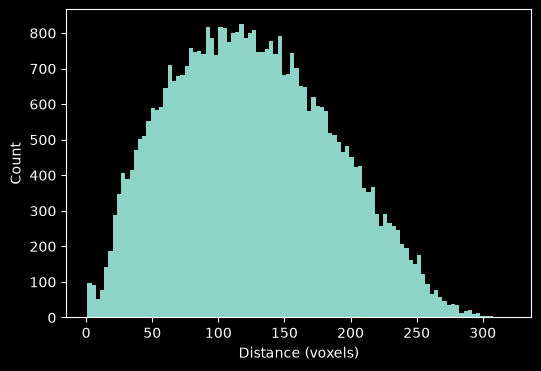

In [188]:
plt.figure(figsize=(6, 4))

plt.hist(cost_matrix.ravel(), bins=100)

plt.xlabel("Distance (voxels)")
plt.ylabel("Count")

plt.show()

In [189]:
from scipy.optimize import linear_sum_assignment

row_ind, col_ind = linear_sum_assignment(cost_matrix)

print(f"Matched pairs: {len(row_ind)}")

Matched pairs: 202


In [190]:
matched_distances = cost_matrix[row_ind, col_ind]

print(f"Minimum : {matched_distances.min():.2f}")
print(f"Mean    : {matched_distances.mean():.2f}")
print(f"Maximum : {matched_distances.max():.2f}")

Minimum : 0.85
Mean    : 4.95
Maximum : 38.66


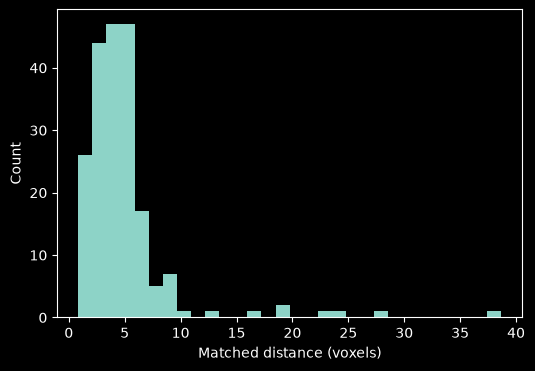

In [191]:
plt.figure(figsize=(6, 4))

plt.hist(matched_distances, bins=30)

plt.xlabel("Matched distance (voxels)")
plt.ylabel("Count")

plt.show()

In [192]:
matches = pd.DataFrame({
    "cell_t": row_ind,
    "cell_t1": col_ind,
    "distance": matched_distances,
})

matches.sort_values(
    "distance",
    ascending=False,
).head(20)

,cell_t,cell_t1,distance
12,12,32,38.655033
82,82,38,27.596625
77,77,53,23.825841
50,50,202,22.691707
48,48,24,19.501111
18,18,10,19.004823
94,94,85,16.405127
121,121,123,12.272538
117,117,132,10.603824
100,100,104,9.638248


In [193]:
MAX_DISTANCE = 12.0

accepted_matches = matches[
    matches["distance"] <= MAX_DISTANCE
    ].copy()

rejected_matches = matches[
    matches["distance"] > MAX_DISTANCE
    ].copy()

In [194]:
print(f"Total assignments : {len(matches)}")
print(f"Accepted          : {len(accepted_matches)}")
print(f"Rejected          : {len(rejected_matches)}")

Total assignments : 202
Accepted          : 194
Rejected          : 8


In [195]:
matched_prev = set(accepted_matches["cell_t"])
matched_next = set(accepted_matches["cell_t1"])

unmatched_prev = sorted(
    set(range(len(detections[0]))) - matched_prev
)

unmatched_next = sorted(
    set(range(len(detections[1]))) - matched_next
)
print(f"Matched previous : {len(matched_prev)}")
print(f"Matched next     : {len(matched_next)}")
print(f"Unmatched prev   : {len(unmatched_prev)}")
print(f"Unmatched next   : {len(unmatched_next)}")

Matched previous : 194
Matched next     : 194
Unmatched prev   : 8
Unmatched next   : 17


In [196]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

MAX_DISTANCE = 12.0

# -----------------------------
# Cost function weights
# -----------------------------
W_DISTANCE = 0.8
W_VOLUME = 0.2

# Reject matches whose volumes differ by more than this ratio
MAX_VOLUME_RATIO = 1.5

# ------------------------------------------------------------
# Initialize tracks using the first frame
# ------------------------------------------------------------

current_track_ids = np.arange(len(detections[0]), dtype=int)
next_track_id = len(current_track_ids)

tracks = []

for cell, track in enumerate(current_track_ids):

    row = detections[0].iloc[cell]

    tracks.append({
        "track_id": track,
        "frame": 0,
        "cell": cell,
        "z": row["centroid_z"],
        "y": row["centroid_y"],
        "x": row["centroid_x"],
    })

# ------------------------------------------------------------
# Process every pair of frames
# ------------------------------------------------------------

for t in range(len(detections) - 1):

    det0 = detections[t]
    det1 = detections[t + 1]

    # -----------------------------
    # Coordinates
    # -----------------------------

    coords0 = det0[
        ["centroid_z", "centroid_y", "centroid_x"]
    ].to_numpy(dtype=float)

    coords1 = det1[
        ["centroid_z", "centroid_y", "centroid_x"]
    ].to_numpy(dtype=float)

    # -----------------------------
    # Distance matrix
    # -----------------------------

    distance_matrix = cdist(coords0, coords1)

    # Normalize to [0,1]
    distance_cost = distance_matrix / MAX_DISTANCE

    # -----------------------------
    # Volume similarity
    # -----------------------------

    vol0 = det0["volume_voxels"].to_numpy(dtype=float)
    vol1 = det1["volume_voxels"].to_numpy(dtype=float)

    volume_cost = (
            np.abs(vol0[:, None] - vol1[None, :])
            / np.maximum(vol0[:, None], vol1[None, :])
    )

    # -----------------------------
    # Combined cost matrix
    # -----------------------------

    cost_matrix = (
            W_DISTANCE * distance_cost
            + W_VOLUME * volume_cost
    )

    # -----------------------------
    # Hungarian assignment
    # -----------------------------

    rows, cols = linear_sum_assignment(cost_matrix)

    matches = pd.DataFrame({
        "cell_t": rows,
        "cell_t1": cols,
        "distance": distance_matrix[rows, cols],
        "cost": cost_matrix[rows, cols],
    })

    # Keep only matches within the maximum movement distance
    accepted = matches[
        matches.distance <= MAX_DISTANCE
        ]

    next_track_ids = np.full(
        len(det1),
        -1,
        dtype=int,
    )

    # --------------------------------------------------------
    # Continue existing tracks
    # --------------------------------------------------------

    for _, row in accepted.iterrows():

        prev_cell = int(row.cell_t)
        next_cell = int(row.cell_t1)

        next_track_ids[next_cell] = current_track_ids[prev_cell]

    # --------------------------------------------------------
    # Start new tracks
    # --------------------------------------------------------

    for cell in np.where(next_track_ids == -1)[0]:

        next_track_ids[cell] = next_track_id
        next_track_id += 1

    # --------------------------------------------------------
    # Save tracks
    # --------------------------------------------------------

    for cell, track in enumerate(next_track_ids):

        row = det1.iloc[cell]

        tracks.append({
            "track_id": track,
            "frame": t + 1,
            "cell": cell,
            "z": row["centroid_z"],
            "y": row["centroid_y"],
            "x": row["centroid_x"],
        })

    print(
        f"{t:03d}->{t+1:03d} : "
        f"{len(accepted):3d} matches | "
        f"{len(det1) - len(accepted):2d} new tracks"
    )

    current_track_ids = next_track_ids

tracks = pd.DataFrame(tracks)

Frame 0->1 shift = (-1.57, 1.52, -4.33)
000->001 : 192 matches | 19 new tracks
Frame 1->2 shift = (-0.67, 0.76, -1.54)
001->002 : 193 matches | 16 new tracks
Frame 2->3 shift = (1.04, -3.41, 2.88)
002->003 : 196 matches | 18 new tracks
Frame 3->4 shift = (-1.01, -3.31, 1.15)
003->004 : 179 matches | 32 new tracks
Frame 4->5 shift = (0.45, 0.53, -2.76)
004->005 : 183 matches | 16 new tracks
Frame 5->6 shift = (-1.13, -9.63, -2.31)
005->006 :  75 matches | 132 new tracks
Frame 6->7 shift = (0.94, 7.32, -0.04)
006->007 : 188 matches | 21 new tracks
Frame 7->8 shift = (-0.69, -1.07, 2.10)
007->008 : 180 matches | 25 new tracks
Frame 8->9 shift = (0.20, 2.11, -1.51)
008->009 : 182 matches | 24 new tracks
Frame 9->10 shift = (0.22, -1.01, -0.58)
009->010 : 190 matches | 19 new tracks
Frame 10->11 shift = (0.30, 0.98, 1.46)
010->011 : 175 matches | 33 new tracks
Frame 11->12 shift = (0.15, -5.96, 0.85)
011->012 :  92 matches | 123 new tracks
Frame 12->13 shift = (-0.34, 4.71, -3.84)
012->013 

In [197]:
import pandas as pd

tracks = pd.DataFrame(tracks)

In [198]:
import napari

track_data = tracks[
    ["track_id", "frame", "z", "y", "x"]
].to_numpy()

viewer = napari.Viewer(ndisplay=3)

viewer.add_tracks(
    track_data,
    tail_length=20,
    head_length=0,
    name="Tracks",
)

viewer.add_points(
    tracks[["frame", "z", "y", "x"]].to_numpy(),
    size=3,
    face_color="red",
    name="Detections",
)

napari.run()

In [199]:
import zarr

ZARR_PATH = (
        DATA_ROOT
        / "biohub_5samples_20timepoints"
        / "train"
        / SAMPLE_ID
        / f"{SAMPLE_ID}.zarr"
)

ARRAY_PATH = ZARR_PATH / "0"

original_volume = zarr.open_array(
    str(ARRAY_PATH),
    mode="r"
)

In [200]:
import napari
import numpy as np

# ------------------------------------------------------------
# Convert tracks to Napari format
# ------------------------------------------------------------

tracks_array = tracks[
    ["track_id", "frame", "z", "y", "x"]
].to_numpy(dtype=float)

points_array = tracks[
    ["frame", "z", "y", "x"]
].to_numpy(dtype=float)

track_ids = tracks["track_id"].to_numpy()

# ------------------------------------------------------------
# Launch Napari
# ------------------------------------------------------------

viewer = napari.Viewer(ndisplay=3)

# Raw microscopy image
viewer.add_image(
    original_volume,
    name="Raw Volume",
    rendering="mip",          # Try "attenuated_mip" as well
    colormap="gray",
    contrast_limits=[
        np.percentile(original_volume, 1),
        np.percentile(original_volume, 99.8),
    ],
)

# Track trajectories
viewer.add_tracks(
    tracks_array,
    name="Tracks",
    tail_length=20,
)

# Cell centroids
viewer.add_points(
    points_array,
    name="Centroids",
    size=4,
    face_color="red",
    properties={
        "track_id": track_ids,
    },
)

napari.run()